In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Module 4.1 (Moment 1): The Theory of Analytical Graphics

#### The Core Problem: Control vs. Simplicity

The entire Python visualization world is built on a fundamental tension:

1.  **Matplotlib:** A low-level, powerful, and *verbose* library. It gives you 100% control over every "artist" (every line, point, and piece of text). This is the **Pythonista's** tool for control.
2.  **Seaborn:** A high-level, statistically-aware library. It gives you 100% of the *statistical logic* (automatically calculating regressions, CIs, histograms, groupings). This is the **Statistician's** tool for insight.

An amateur uses one or the other. A professional uses *both at the same time*. Our goal in this module is to learn how to **force Matplotlib's control onto Seaborn's statistical power.**

#### Part 1: The Matplotlib Foundation (The Two APIs)

To control Seaborn, you must first understand the architecture of Matplotlib. Matplotlib has two "APIs" or ways of being used. This is the single most important concept.

**1. The `pyplot` (State-Machine) API**
This is what 90% of beginners learn. It works like a simple notebook. Matplotlib keeps track of *one* "active" plot, and all commands (`plt.title`, `plt.plot`) are applied to it.

  * **Analogy:** You have *one* piece of paper on your desk. `plt.plot()` draws on it. `plt.title()` writes on it.
  * **Code Example:**
    ```python
    plt.plot([1, 2, 3], [10, 20, 15]) # Draws on the "active" plot
    plt.title("My Plot")              # Writes on the "active" plot
    plt.show()
    ```
  * **Limitation:** This is fine for one plot, but it becomes a confusing nightmare for building a dashboard. How do you tell it which of your four subplots is "active"? It becomes unwieldy.

**2. The Object-Oriented (OO) API (The Professional's Way)**
This is our focus. You *never* let Matplotlib guess what plot is active. You *explicitly* create your canvas (the `Figure`) and your subplots (the `Axes`) as objects. You then call methods *directly* on those objects.

  * **Analogy:** You are a manager. You create a `Figure` (the dashboard canvas) and then you create `Axes` objects (e.g., `ax1`, `ax2`) for each subplot. You give explicit commands: "ax1, set your title to 'Age Distribution'." "ax2, draw this scatter plot."

  * **The Golden Code (`plt.subplots`)**: This is the command that creates both the canvas and the subplots at the same time.

    ```python
    # Create a figure (fig) and ONE subplot (ax)
    fig, ax = plt.subplots(figsize=(8, 6))

    # Now, call methods on the 'ax' object
    ax.plot([1, 2, 3], [10, 20, 15])
    ax.set_title("My Plot (OO API)")
    ax.set_xlabel("Time")
    plt.show()
    ```

  * **For Dashboards (Our Goal):**

    ```python
    # Create a 2x2 dashboard
    # 'fig' is the whole canvas
    # 'axes' is a 2D NumPy array of the four subplots
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    # Access the subplots by their index
    axes[0, 0].set_title("Top-Left Plot")
    axes[0, 1].set_title("Top-Right Plot")
    axes[1, 0].set_title("Bottom-Left Plot")
    axes[1, 1].set_title("Bottom-Right Plot")

    plt.show()
    ```

**Why this is advanced:** This OO approach is the *only* way to build complex, multi-plot figures. It is the key to unlocking dashboard-style analysis.

#### Part 2: The Seaborn Philosophy (Two Kinds of Functions)

Now that we have our `ax` objects, we can see how Seaborn interacts with them. Seaborn functions are *not* all the same. They fall into two distinct families.

**1. Axes-Level Functions**

  * **What they are:** `scatterplot()`, `boxplot()`, `histplot()`, `regplot()`, `pointplot()`, `kdeplot()`, `violinplot()`, etc.

  * **Key Property:** They are designed to draw *onto a specific Matplotlib `Axes`*.

  * **How you use them:** You pass your `ax` object to them using the **`ax=` parameter**.

  * **This is the key:** This is the "golden bridge" that connects Seaborn's statistical power to Matplotlib's control.

    ```python
    fig, ax = plt.subplots()
    sns.histplot(data=df, x='age', kde=True, ax=ax) # Tell Seaborn to draw on 'ax'
    ax.set_title("My Custom Title")
    ```

**2. Figure-Level Functions**

  * **What they are:** `jointplot()`, `pairplot()`, `FacetGrid()`, `clustermap()`.
  * **Key Property:** They are *not* designed to draw on your existing `ax`. They *create and manage their own* `Figure` and `Axes` grid.
  * **Why:** A `jointplot` is not one plot; it is *three* (the main scatter, and two marginal histograms). A `pairplot` is a complex grid. These functions *are* the dashboard.
  * **Limitation:** Because they "own" the figure, they are harder to customize. You cannot easily put a `jointplot` into the top-left corner of your `plt.subplots(2, 2)` grid.

**The Statistician-Pythonista's Rule:**

> You will primarily use **Axes-level functions** (`scatterplot`, `histplot`, etc.) and pass them to the **Matplotlib OO API (`ax=`)**. This gives you maximum statistical power *and* maximum layout control. You use Figure-level functions (`pairplot`) for quick, exploratory "first looks".

#### Part 3: The Statistician's Toolbox (Beyond Basic Plots)

Your `plot_seaborn` function is great, but it treats all plots as equal. A true statistician knows *why* to pick one plot over another for its inferential power.

**1. Visualizing Inference (Not Just Data)**
You should not just plot points. You should plot *what the points imply*.

  * **`sns.regplot()` (Regression Plot):**

      * **What it is:** This is a `scatterplot` *plus* a linear regression.
      * **What it does:** It automatically:
        1.  Runs a fast linear regression ($y \sim x$).
        2.  Plots the resulting regression line.
        3.  Calculates and plots the 95% confidence interval for that regression line (the light-colored "cone" around the line).
      * **Statistical Read:** If the confidence interval "cone" is very wide, it means the relationship is weak and you have low confidence in the slope. If it is tight, the relationship is strong.

  * **`sns.pointplot()` (Point Plot):**

      * **What it is:** This chart looks like a simple line chart, but it is for *categorical* data.
      * **What it does:** The dot is the `mean` (or other estimator) for that category. The vertical line is the **95% confidence interval for the mean**.
      * **Statistical Read:** This is far superior to a `barplot`. A `barplot` only shows the mean. A `pointplot` shows the mean *and* its uncertainty. If the confidence intervals for two categories do not overlap, you have strong evidence that their means are *statistically significantly different*.

**2. Visualizing Distributions (Rigorously)**
You already know `histplot` and `boxplot`.

  * **`sns.violinplot()`:**

      * **What it is:** The perfect marriage of a `boxplot` and a `kdeplot`.
      * **What it does:** It shows a `boxplot` in the center, and on both sides, it shows the full density (the "shape") of the data.
      * **Statistical Read:** It answers questions a `boxplot` cannot. For example, a `boxplot` might look symmetric, but the `violinplot` could reveal that the data is **bimodal** (has two peaks).

  * **`sns.ecdfplot()` (Empirical Cumulative Distribution Function):**

      * **What it is:** A very powerful and often superior alternative to a histogram.
      * **What it does:** Instead of bins, it plots a step function. The Y-axis is "what percentage of my data is less than or equal to this X-value".
      * **Statistical Read:** It is fantastic for reading percentiles. To find the median (50th percentile), you just find Y=0.50 and look at the corresponding X. It also shows skew and modality clearly, without the "binning bias" of a histogram.

**3. Visualizing Multi-Variable Relationships (Grids)**
These are the Figure-level functions we discussed.

  * **`sns.pairplot(df, hue='category')`:**
      * **What it is:** The single most powerful "first look" tool in all of data science. It creates a matrix of scatterplots for every numeric variable against every other, and histograms/KDEs on the diagonal.
      * **Statistical Read:** You can diagnose *all* pairwise relationships (linear, non-linear, correlated, uncorrelated) and *all* distributions in one command.
  * **`sns.jointplot(x=..., y=..., kind='kde'/'hex')`:**
      * **What it is:** A deep dive into *two* variables. It shows the main `scatterplot` (or a `kde` or `hexbin` plot for overplotting) and the individual histograms/KDEs for both X and Y in the margins.
  * **`sns.clustermap(df.corr())`:**
      * **What it is:** A `heatmap` *plus* hierarchical clustering.
      * **Statistical Read:** It automatically re-orders your correlation matrix so that highly-correlated features are grouped together, revealing the hidden "blocks" of co-related variables in your dataset.

#### Part 4: Professional Polish (Color, Context, and Annotation)

1.  **Color as Information (Palettes):** Color is not decoration; it is an aesthetic, just like `x` and `y`.

      * **Categorical (`palette='Set1'` or `'tab10'`):** For distinct, non-ordered groups (e.g., `Country`: USA, Brazil, UK). Use high-contrast, different colors.
      * **Sequential (`palette='Blues'` or `'viridis'`):** For numeric data that goes from low-to-high (e.g., `Price`: 0 to 100). Use a gradient of a single color.
      * **Diverging (`palette='coolwarm'` or `'vlag'`):** For numeric data with a *meaningful center* (like 0). (e.g., `Correlation`: -1 to +1, or `Profit`: -50 to +50). Use two different colors that diverge from a neutral center.

2.  **Context (`sns.set_context()`):**

      * This scales all plot elements (text, lines) for its final destination.
      * `sns.set_context('notebook')`: Default.
      * `sns.set_context('paper')`: Smaller, for academic papers.
      * `sns.set_context('talk')`: Bolder, for presentations.
      * `sns.set_context('poster')`: Huge, for posters.

3.  **Annotation (`ax.annotate()`):**

      * This is how you *tell the story*. A plot shows *what*, an annotation tells the *so what*.
      * You use it to add your statistical findings (like the $r^2$ value from a regression) or to point an arrow at a specific, interesting outlier.



### Module 4.2 (Moment 2): The Practice (The "How")

In Moment 1, we established that an advanced user *never* just calls `plt.plot()`. They control the canvas. Let's start by setting up our tools and our data.

#### 1. Setup: Imports and Data Loading

First, we import our libraries and load the data. This is the only "setup" step. Notice we are importing `matplotlib.pyplot` *as* `plt`, but we are also importing `scipy.stats`, our statistical workhorse.


```python
from scipy import stats  # Our new statistical tool
from sklearn.datasets import fetch_openml

# Set a professional, clean plot style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Load the Ames Housing dataset
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.data.copy()
df["SalePrice"] = housing.target

# In a real project (Module 8), we would impute missing data.
# For this visualization module, we will simplify by dropping columns
# with any missing values to ensure all plots work.
df = df.dropna(axis=1)

# Create the log-transformed SalePrice we discussed in Module 3
# This is our first statistical intervention
df["SalePrice_Log"] = np.log(df["SalePrice"])

print("Ames Housing data loaded and prepped.")
print(df[["SalePrice", "SalePrice_Log", "GrLivArea", "Neighborhood"]].head())
```

#### 2. The Foundation: The Matplotlib Object-Oriented (OO) API

Our goal is to build a 2x2 dashboard. We do *not* start by plotting. We start by building the *scaffolding*. This is the Object-Oriented API.

```python
# This is the "golden code"
# We create ONE Figure (fig) and a 2x2 grid of Axes (axes)
# 'fig' is the entire canvas, like the 'OlistAnalyzer' class
# 'axes' is a 2D NumPy array of the subplots, like the methods
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# 'axes' is a 2D NumPy array:
# axes[0, 0] = Top-left
# axes[0, 1] = Top-right
# axes[1, 0] = Bottom-left
# axes[1, 1] = Bottom-right

print(f"Type of fig: {type(fig)}")
print(f"Type of axes: {type(axes)}")
print(f"Shape of axes: {axes.shape}")
```


This is the **control** we need. We now have four empty 'canvases' (`ax` objects) and we can tell Seaborn *exactly* where to draw.


#### 3. Plot 1 (Top-Left): The Statistical Transformation

**Goal:** Visually prove that `SalePrice` is right-skewed and that a log-transform fixes it.

**Statistician's Thought:** A histogram is good, but a Q-Q plot (or probability plot) is the *rigorous* statistical test for normality. A straight line means the data is normal. We will plot *both*.

**Pythonista's Plan:** We can't use `plt.subplots(1, 2)` here because we've already defined our 2x2 grid. We must use `axes[0, 0]` and `axes[0, 1]`.

```python
# The "Problem" Plot
ax_tl = axes[0, 0]
sns.histplot(data=df, x="SalePrice", kde=True, ax=ax_tl, color="C0")
ax_tl.set_title("Problem: 'SalePrice' is Right-Skewed", fontweight="bold")
ax_tl.set_xlabel("Sale Price ($)")


# --- Plot 2: Top-Right (axes[0, 1]) ---
# The "Statistical Test" Plot
ax_tr = axes[0, 1]
stats.probplot(
	df["SalePrice_Log"],  # Use the log-transformed data
	plot=ax_tr,  # Tell scipy.stats to plot on *this* axes
)
ax_tr.set_title("Solution: Log-Transformed 'SalePrice' is Normal", fontweight="bold")
ax_tr.set_xlabel("Theoretical Quantiles (Normal)")
ax_tr.set_ylabel("Ordered Log(SalePrice) Values")
```

**Code Breakdown (This is the critical part):**

  * `ax=ax_tl`: We passed our specific top-left `Axes` object to Seaborn's `histplot`. Seaborn did its statistical calculation and drew it on *our* canvas, not its own.
  * `plot=ax_tr`: This is the `scipy.stats` equivalent of the `ax=` parameter. We are telling the `probplot` function to draw its results on our top-right `Axes`.
  * **Result:** We have just performed and visualized a statistical transformation, proving its necessity. The Q-Q plot's points fall almost perfectly on the red line, confirming our log-transformed data is now normal and ready for linear models.


#### 4. Plot 2 (Bottom-Left): Statistical Inference with `regplot`

**Goal:** Show the key relationship between `SalePrice` and `GrLivArea` (living area) and quantify its strength.

**Statistician's Thought:** A `scatterplot` is good, but a `regplot` is better. It automatically runs a linear regression and, crucially, plots the **95% confidence interval** (the "cone"). This cone *is* statistical inference—it shows the uncertainty in our regression line.

**Pythonista's Plan:**

1.  Draw the `regplot` on `axes[1, 0]`.
2.  Calculate the Pearson correlation coefficient ($r$).
3.  Use `ax.annotate()` to write the $r$-value onto the plot.

```python
# --- Plot 3: Bottom-Left (axes[1, 0]) ---
ax_bl = axes[1, 0]

# Use sns.regplot
sns.regplot(
	data=df,
	x="GrLivArea",
	y="SalePrice",
	ax=ax_bl,
	line_kws={"color": "red", "linestyle": "--"},  # Customize the line
	scatter_kws={"alpha": 0.3},  # Make points transparent
)
ax_bl.set_title("Key Relationship: Price vs. Living Area", fontweight="bold")
ax_bl.set_xlabel("Above-Ground Living Area (SqFt)")
ax_bl.set_ylabel("Sale Price ($)")

# Statistician Challenge: Add the correlation
corr_coef, p_value = stats.pearsonr(df["GrLivArea"], df["SalePrice"])
annotation_text = f"$r = {corr_coef:.2f}$"  # Format as math text

# Use ax.annotate() to place the text
ax_bl.annotate(
	text=annotation_text,
	xy=(0.05, 0.90),  # (x, y) position in *relative* axes coordinates (0-1)
	xycoords="axes fraction",  # Tell it we're using relative coordinates
	fontsize=14,
	fontweight="bold",
	bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8),
)
```

**Code Breakdown:**

  * `sns.regplot(..., ax=ax_bl)`: We again directed Seaborn to our specific subplot.
  * `stats.pearsonr(...)`: We used `scipy.stats` to get the $r$-value.
  * `ax.annotate(...)`: This is the advanced Matplotlib technique. We didn't just add text; we placed it at a *relative position* (5% from the left, 90% from the bottom) using `xycoords='axes fraction'`. This is a robust way to place text that doesn't depend on the data's scale.

#### 5. Plot 3 (Bottom-Right): The Correlation Heatmap

**Goal:** Show the relationships between all key features in a single, dense matrix.

**Statistician's Thought:** We need a way to find *multicollinearity* (features that are highly correlated with *each other*) and to identify the strongest *predictors* (features highly correlated with `SalePrice`). A heatmap of a correlation matrix is the tool.

**Pythonista's Plan:**

1.  Define our list of important features.
2.  Calculate the `pandas.corr()` matrix for just those features.
3.  Use `sns.heatmap` to plot it on `axes[1, 1]`.
4.  Use a *diverging* colormap (`cmap`) centered at 0. This is crucial.


```python
# --- Plot 4: Bottom-Right (axes[1, 1]) ---
ax_br = axes[1, 1]

# 1. Define feature subset
features = [
	"SalePrice",
	"GrLivArea",
	"TotalBsmtSF",
	"1stFlrSF",
	"FullBath",
	"TotRmsAbvGrd",
	"YearBuilt",
]
corr_matrix = df[features].corr()

# 2. Use sns.heatmap
sns.heatmap(
	corr_matrix,
	ax=ax_br,
	annot=True,  # Write the correlation values in the cells
	fmt=".2f",  # Format them to 2 decimal places
	cmap="vlag",  # Use a "blue-white-red" diverging palette
	center=0,  # Center the color map at 0
	linewidths=0.5,
)
ax_br.set_title("Correlation Matrix of Key Features", fontweight="bold")
```


**Code Breakdown:**

  * `cmap="vlag", center=0`: This is the most important *statistical* part. We are telling the plot that 0 is the neutral point (white). Strong positive correlations (like `SalePrice` and `GrLivArea` at 0.71) are red, and strong negative correlations are blue. This is far superior to a simple sequential palette (like "Blues") which would map 0 to a color, implying it has a value.


#### 6. Final Polish: The Grand Finale

Now that all four `axes` are populated, we add the final touches to the `figure` object.

```python
# Add a single, overarching title for the entire dashboard
fig.suptitle(
	"Ames Housing: A Statistician-Pythonista Dashboard", fontsize=20, fontweight="bold"
)

# This command automatically adjusts plot parameters for a tight layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # 'rect' leaves space for the suptitle

# Finally, show the plot
plt.show()
```

In [2]:
from scipy import stats
from sklearn.datasets import fetch_openml

# Load the Ames Housing dataset
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.data.copy()
df["SalePrice"] = housing.target

# In a real project (Module 8), we would impute missing data.
# For this visualization module, we will simplify by dropping columns
# with any missing values to ensure all plots work.
df = df.dropna(axis=1)

# Create the log-transformed SalePrice we discussed in Module 3
# This is our first statistical intervention
df["SalePrice_Log"] = np.log(df["SalePrice"])

display(df[["SalePrice", "SalePrice_Log", "GrLivArea", "Neighborhood"]].head())

,SalePrice,SalePrice_Log,GrLivArea,Neighborhood
0,208500,12.247694,1710,CollgCr
1,181500,12.109011,1262,Veenker
2,223500,12.317167,1786,CollgCr
3,140000,11.849398,1717,Crawfor
4,250000,12.429216,2198,NoRidge


Type of fig: <class 'matplotlib.figure.Figure'>
Type of axes: <class 'numpy.ndarray'>
Shape of axes: (2, 2)


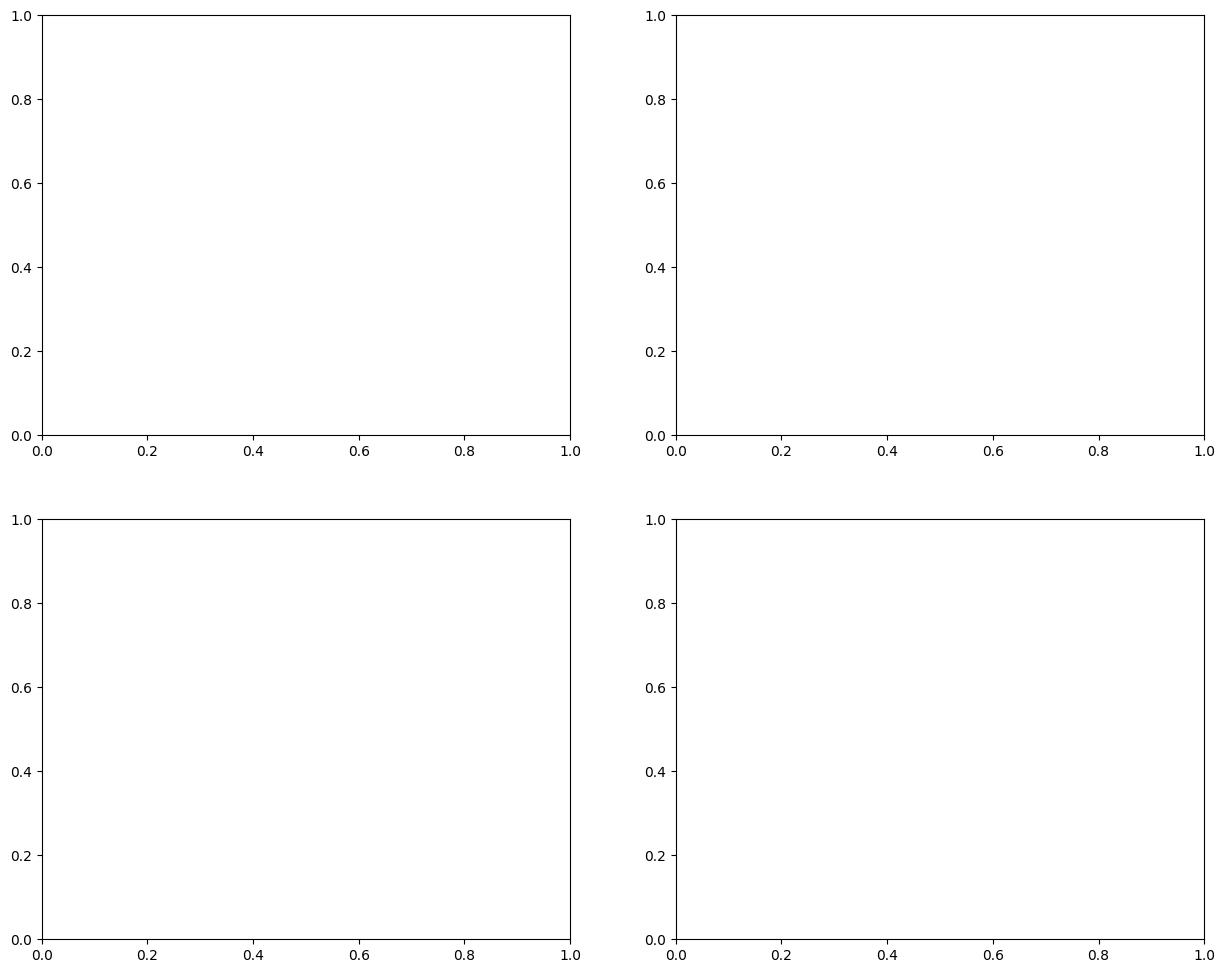

In [3]:
# This is the "golden code"
# We create ONE Figure (fig) and a 2x2 grid of Axes (axes)
# 'fig' is the entire canvas, like the 'OlistAnalyzer' class
# 'axes' is a 2D NumPy array of the subplots, like the methods
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# 'axes' is a 2D NumPy array:
# axes[0, 0] = Top-left
# axes[0, 1] = Top-right
# axes[1, 0] = Bottom-left
# axes[1, 1] = Bottom-right

print(f"Type of fig: {type(fig)}")
print(f"Type of axes: {type(axes)}")
print(f"Shape of axes: {axes.shape}")

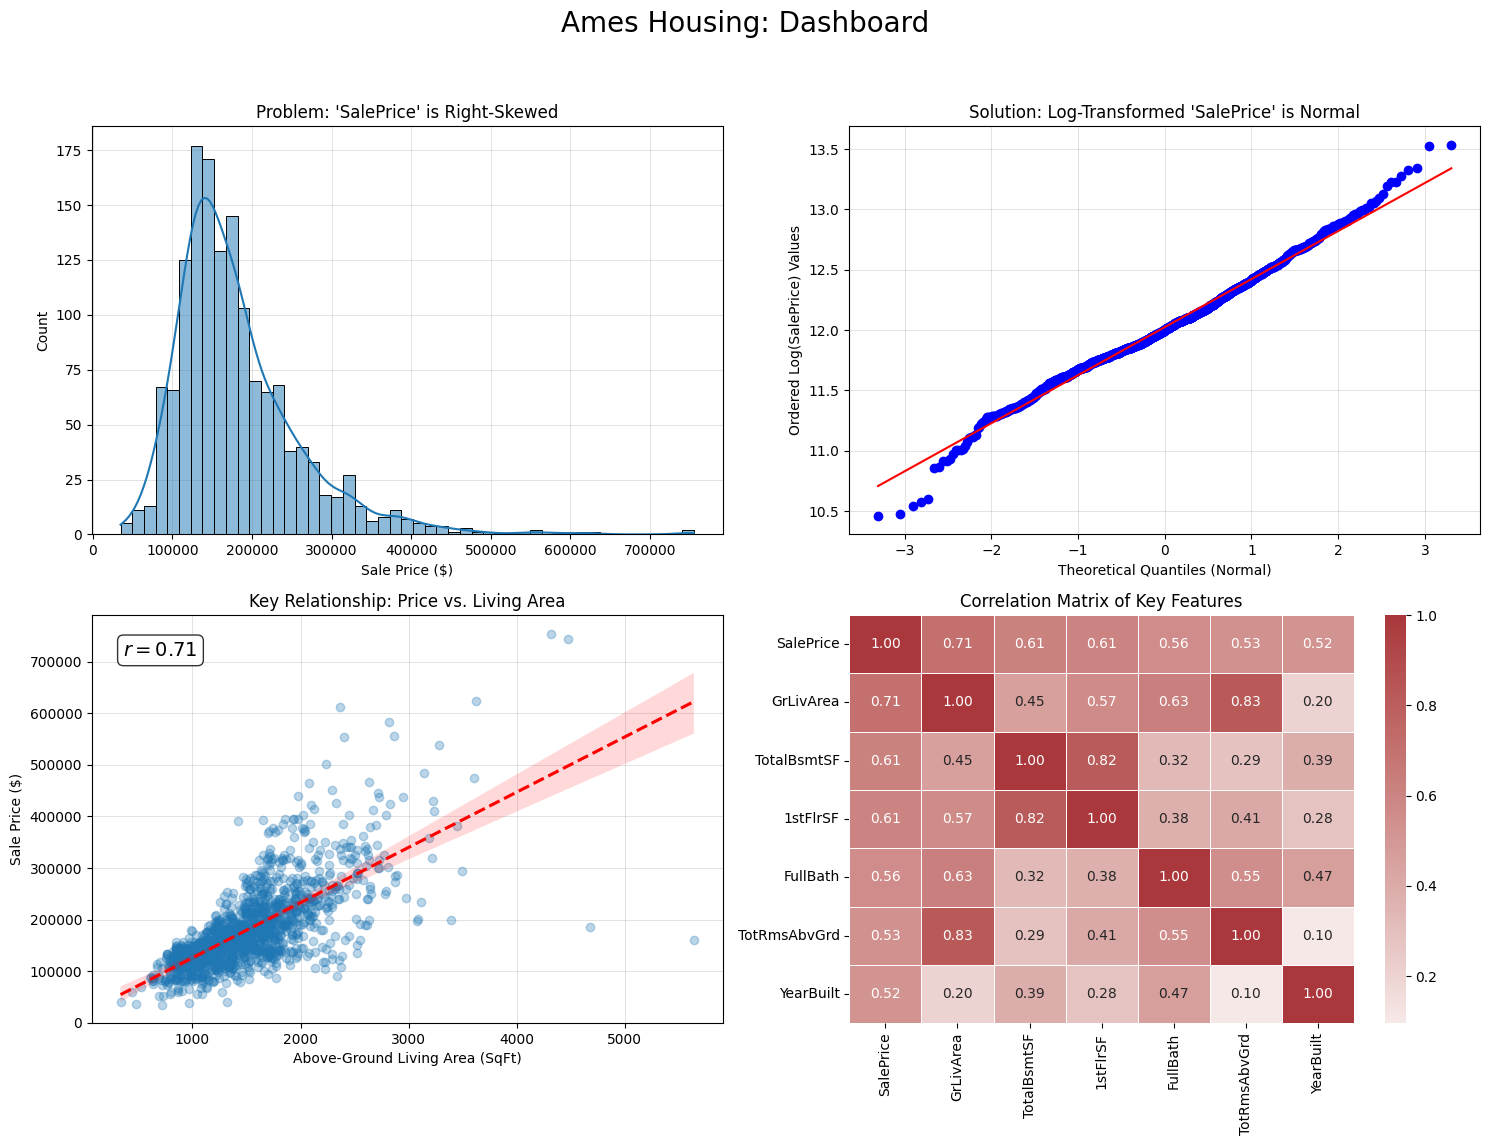

In [5]:
# Create a 2x2 subplot grid for comprehensive data visualization
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

# Plot 1: Top-Left - Distribution Analysis
ax_tl = axes[0, 0]
# Visualize the raw SalePrice distribution to identify skewness
sns.histplot(data=df, x="SalePrice", kde=True, ax=ax_tl, color="C0")
ax_tl.set_title("Problem: 'SalePrice' is Right-Skewed")
ax_tl.set_xlabel("Sale Price ($)")
ax_tl.grid(linewidth=0.4, alpha=0.4, color="grey")
ax_tl.set_axisbelow(True)

# Plot 2: Top-Right - Normality Check
ax_tr = axes[0, 1]
# Q-Q plot to verify if log transformation normalizes the distribution
stats.probplot(
	df["SalePrice_Log"],  # Use log-transformed data for normality assessment
	plot=ax_tr,
)
ax_tr.set_title("Solution: Log-Transformed 'SalePrice' is Normal")
ax_tr.set_xlabel("Theoretical Quantiles (Normal)")
ax_tr.set_ylabel("Ordered Log(SalePrice) Values")
ax_tr.grid(linewidth=0.4, alpha=0.4, color="grey")
ax_tr.set_axisbelow(True)

# Plot 3: Bottom-Left - Correlation Analysis
ax_bl = axes[1, 0]
# Scatter plot with regression line to show relationship between living area and price
sns.regplot(
	data=df,
	x="GrLivArea",
	y="SalePrice",
	ax=ax_bl,
	line_kws={"color": "red", "linestyle": "--"},  # Regression line styling
	scatter_kws={"alpha": 0.3},  # Point transparency for overlapping data
)
ax_bl.set_title("Key Relationship: Price vs. Living Area")
ax_bl.set_xlabel("Above-Ground Living Area (SqFt)")
ax_bl.set_ylabel("Sale Price ($)")
ax_bl.grid(linewidth=0.4, alpha=0.4, color="grey")
ax_bl.set_axisbelow(True)

# Calculate and display Pearson correlation coefficient
corr_coef, p_value = stats.pearsonr(df["GrLivArea"], df["SalePrice"])
annotation_text = f"$r = {corr_coef:.2f}$"  # Format as mathematical notation

# Add correlation coefficient as annotation
ax_bl.annotate(
	text=annotation_text,
	xy=(0.05, 0.90),  # Position in axes-relative coordinates
	xycoords="axes fraction",
	fontsize=14,
	fontweight="bold",
	bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8),
)

# Plot 4: Bottom-Right - Feature Correlation Matrix
ax_br = axes[1, 1]

# Select key features for correlation analysis
features = [
	"SalePrice",
	"GrLivArea",
	"TotalBsmtSF",
	"1stFlrSF",
	"FullBath",
	"TotRmsAbvGrd",
	"YearBuilt",
]
corr_matrix = df[features].corr()

# Heatmap visualization of correlation matrix
sns.heatmap(
	corr_matrix,
	ax=ax_br,
	annot=True,  # Display correlation values
	fmt=".2f",  # Two decimal places
	cmap="vlag",  # Diverging colormap (blue-white-red)
	center=0,  # Center colormap at zero
	linewidths=0.5,
)
ax_br.set_title("Correlation Matrix of Key Features")
ax_br.grid(linewidth=0.4, alpha=0.4, color="grey")
ax_br.set_axisbelow(True)

# Final Dashboard Configuration
fig.suptitle("Ames Housing: Dashboard", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to accommodate suptitle
plt.show()


### Module 4.3 (Moment 3): The Advanced Dashboard Challenge

**Dataset:** We will use the **"Diamonds" dataset**, which is built into Seaborn. It is a classic, rich dataset with a mix of continuous (`carat`, `price`), ordinal categorical (`cut`, `color`, `clarity`), and nominal categorical data. It is perfect for this challenge.

**Your Objective:**
Create a single, cohesive **2x2 dashboard** using the Matplotlib Object-Oriented (OO) API. You must use `plt.subplots(2, 2, ...)` and pass the `ax` objects to Seaborn to tell it where to draw.

### Minimal Starter Code (Dataset Only)


In [6]:
# Load the "diamonds" dataset
df_diamonds = sns.load_dataset("diamonds")

# Verify the data
print(df_diamonds.info())
display(df_diamonds.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Your 2x2 Dashboard Tasks

Here are the four plots you must create, one for each `Axes` in your grid.

1.  **Top-Left Plot (`axes[0, 0]`): The "Blob" Problem & Solution**

      * **Task:** The relationship between `carat` and `price` is exponential, not linear. Plotting it directly creates a "blob" (like our Scenario 2 from Module 3).
      * **Statistician's Challenge:** You must fix this. On `axes[0, 0]`, plot a `scatterplot` of the **log-transformed `price`** vs. the **log-transformed `carat`**.
      * **Goal:** Add `alpha=0.1` to the plot to handle the massive overplotting (there are \~54,000 data points) and show the true, linear relationship.

2.  **Top-Right Plot (`axes[0, 1]`): The Correlation Heatmap**

      * **Task:** Select the key *numeric* variables: `price`, `carat`, `depth`, `table`, `x`, `y`, and `z`.
      * **Implementation:** Calculate the Pearson correlation matrix (`.corr()`) for *only* these features.
      * **Goal:** Plot this matrix as a `heatmap` on `axes[0, 1]`. Use a diverging colormap (`cmap='coolwarm'` or `'vlag'`), center it at 0 (`center=0`), and add the annotations (`annot=True`, `fmt='.1f'`).

3.  **Bottom-Left Plot (`axes[1, 0]`): Advanced Distribution Comparison**

      * **Task:** We want to see the *full distribution* of `price` for each category of `cut`.
      * **Statistician's Challenge:** A `boxplot` would be okay, but a `violinplot` is better as it shows the *shape* of the distribution (where the density is).
      * **Implementation:** Use `sns.violinplot` to plot `price` vs. `cut`.
      * **Pythonista Challenge:** The `cut` variable is *ordinal* (Fair, Good, Very Good, Premium, Ideal). You must enforce this logical order by passing a list `cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']` to the `order=` parameter of your plot.

4.  **Bottom-Right Plot (`axes[1, 1]`): Inference for Categorical Data**

      * **Task:** We want to know the *average price* for each category of `clarity`.
      * **Statistician's Challenge:** A `barplot` only shows the mean. We need to see the *uncertainty*. Use `sns.pointplot` to plot `price` vs. `clarity`.
      * **Goal:** The `pointplot` will automatically calculate and display the mean and its 95% confidence interval. This allows you to visually infer which differences in clarity are statistically significant (i.e., when their CIs do not overlap).

### Final Requirements

  * Use `fig.suptitle("Advanced Diamond Analysis Dashboard")` to give your entire figure a master title.
  * Use `plt.tight_layout()` at the end to ensure your plots are clean and do not overlap.

In [7]:
df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [10]:
# Recode clarity to a correct ordinal order
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
df_diamonds = df_diamonds.copy()
df_diamonds["clarity"] = pd.Categorical(
	df_diamonds["clarity"], categories=clarity_order, ordered=True
)


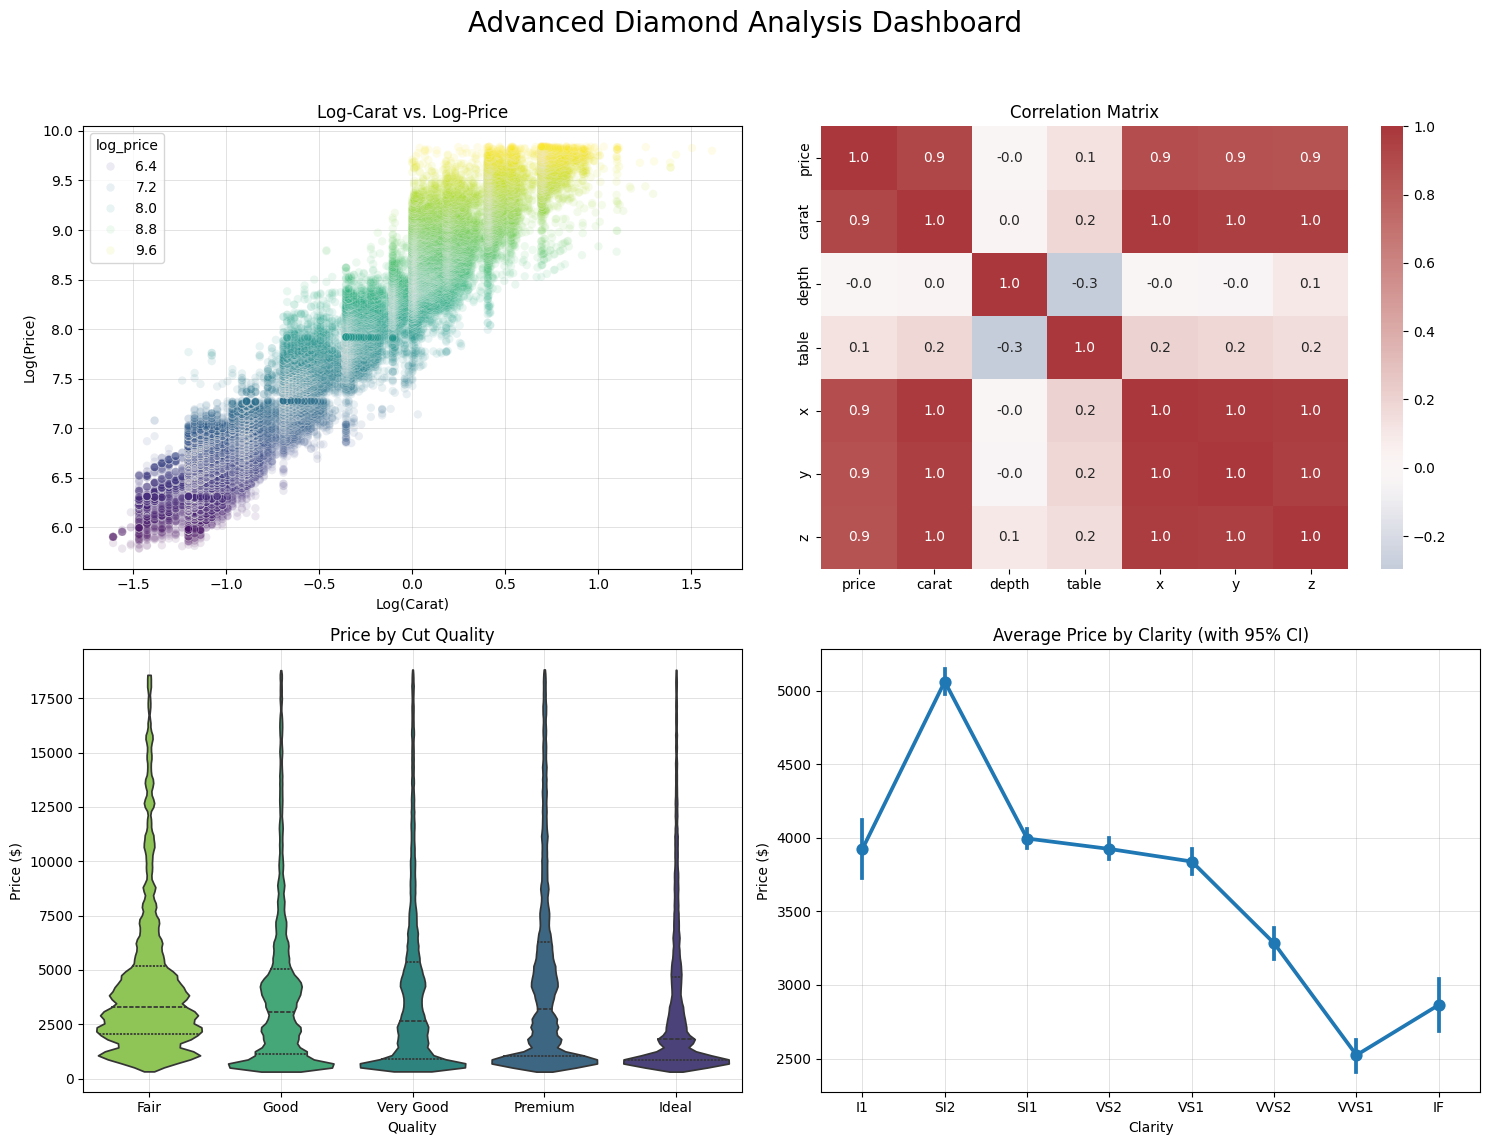

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
fig.suptitle("Advanced Diamond Analysis Dashboard", fontsize=20)

# Task 1
df_diamonds = df_diamonds[df_diamonds["carat"] > 0].copy()
df_diamonds["log_carat"] = np.log(df_diamonds["carat"])
df_diamonds["log_price"] = np.log(df_diamonds["price"])
ax_tl = axes[0, 0]
sns.scatterplot(
	data=df_diamonds,
	x="log_carat",
	y="log_price",
	ax=ax_tl,
	palette="viridis",
	hue="log_price",
	alpha=0.1,
)
ax_tl.set(title="Log-Carat vs. Log-Price", xlabel="Log(Carat)", ylabel="Log(Price)")
ax_tl.grid(linewidth=0.4, alpha=0.4, color="grey")
ax_tl.set_axisbelow(True)

# Task 2
numeric_vars = df_diamonds[["price", "carat", "depth", "table", "x", "y", "z"]]
corr_matrix = numeric_vars.corr()
ax_tr = axes[0, 1]
sns.heatmap(corr_matrix, cmap="vlag", center=0, annot=True, fmt=".1f", ax=ax_tr)
ax_tr.set_title("Correlation Matrix")
ax_tr.grid(linewidth=0.4, alpha=0.4, color="grey")
ax_tr.set_axisbelow(True)

# Task 3
ax_bl = axes[1, 0]
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
sns.violinplot(
	data=df_diamonds,
	x="cut",
	y="price",
	order=cut_order,
	inner="quartile",
	cut=0,  # don’t extend beyond data range
	density_norm="width",
	bw_adjust=0.2,
	hue="cut",
	palette="viridis",
	ax=ax_bl,
)
ax_bl.set(title="Price by Cut Quality", xlabel="Quality", ylabel="Price ($)")
ax_bl.grid(linewidth=0.4, alpha=0.4, color="grey")
ax_bl.set_axisbelow(True)

# Task 4
ax_br = axes[1, 1]
sns.pointplot(data=df_diamonds, x="clarity", y="price", ax=ax_br)
ax_br.set(
	title="Average Price by Clarity (with 95% CI)", xlabel="Clarity", ylabel="Price ($)"
)
ax_br.grid(linewidth=0.4, alpha=0.4, color="grey")
ax_br.set_axisbelow(True)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()